✅ Features: 41 | Target distribution: {1: 59998, 0: 40002}

✅ Accuracy: 0.9184
✅ AUC:      0.9403
✅ Mean PAC: 0.3965


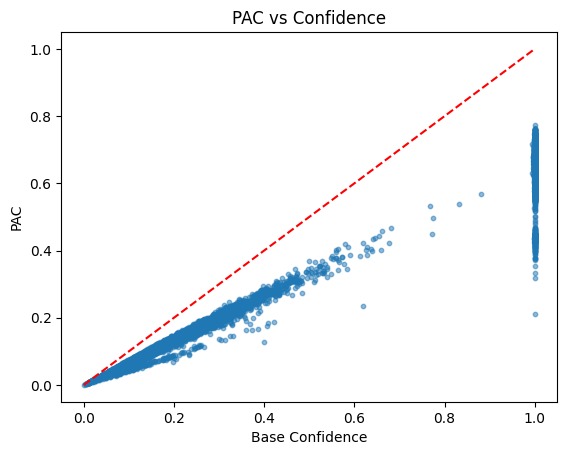


⚠️ Patients flagged for review (PAC < 0.3): 9483


In [ ]:
# ✅ LOAD & VALIDATE YOUR ACTUAL DATASET
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Load your file (make sure filename matches!)
df = pd.read_csv('/content/diabetes_dataset.csv')

# ✅ Use your actual target
y = df['diagnosed_diabetes']  # 0 = No, 1 = Yes

# ✅ Define features (exclude target and stage)
feature_cols = [col for col in df.columns if col not in ['diagnosed_diabetes', 'diabetes_stage']]
X = df[feature_cols]

# Encode categorical variables (gender, ethnicity, etc.)
X = pd.get_dummies(X, drop_first=True)

print(f"✅ Features: {X.shape[1]} | Target distribution: {y.value_counts().to_dict()}")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train model
model = xgb.XGBClassifier(n_estimators=150, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predict
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Compute PAC using 'age' and 'gender' as key provenance attributes
# First, align encoded feature names for gender and age
age_col = 'age'
gender_prefix = 'gender_'

# Get original age and gender for test set (before encoding)
X_test_original = df.loc[X_test.index, ['age', 'gender']]

# Fit NN on TRAINING set (encoded)
nn = NearestNeighbors(n_neighbors=100).fit(X_train)
_, indices = nn.kneighbors(X_test)

pac_scores = []
for i in range(len(X_test)):
    neighbors_X_orig = df.loc[X_train.iloc[indices[i]].index, ['age', 'gender']]
    test_age = X_test_original.iloc[i]['age']
    test_gender = X_test_original.iloc[i]['gender']

    # Gender match rate
    gender_match = (neighbors_X_orig['gender'] == test_gender).mean()
    # Age similarity (normalize by range)
    age_diff = np.abs(neighbors_X_orig['age'] - test_age).mean()
    age_sim = max(0, 1 - age_diff / 60)  # assuming age 18-80 → max diff ~60

    similarity = 0.5 * gender_match + 0.5 * age_sim
    pac = y_proba[i] * similarity
    pac_scores.append(pac)

pac_scores = np.array(pac_scores)

# Results
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print(f"✅ Mean PAC: {pac_scores.mean():.4f}")

# Plot
plt.scatter(y_proba, pac_scores, alpha=0.5, s=10)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('Base Confidence'); plt.ylabel('PAC'); plt.title('PAC vs Confidence')
plt.show()

print(f"\n⚠️ Patients flagged for review (PAC < 0.3): {np.sum(pac_scores < 0.3)}")

🔍 Loading dataset...
✅ Loaded 100,000 rows and 31 columns.
✅ Encoded 6 categorical features.
✅ Final feature set: 29 features

SplitOptions: Train=80,000, Test=20,000

🚀 Training XGBoost model...

📊 Baseline Model Performance:
   Accuracy: 0.9196
   AUC:      0.9421
   Brier:    0.0668

🔍 Computing Provenance-Aware Confidence (PAC) using k=100 neighbors...
✅ PAC computed for 20,000 patients.

📈 PAC Analysis:
   Mean Base Confidence: 0.5982
   Mean PAC:             0.4240
   Correlation (PAC vs Base): 0.9927


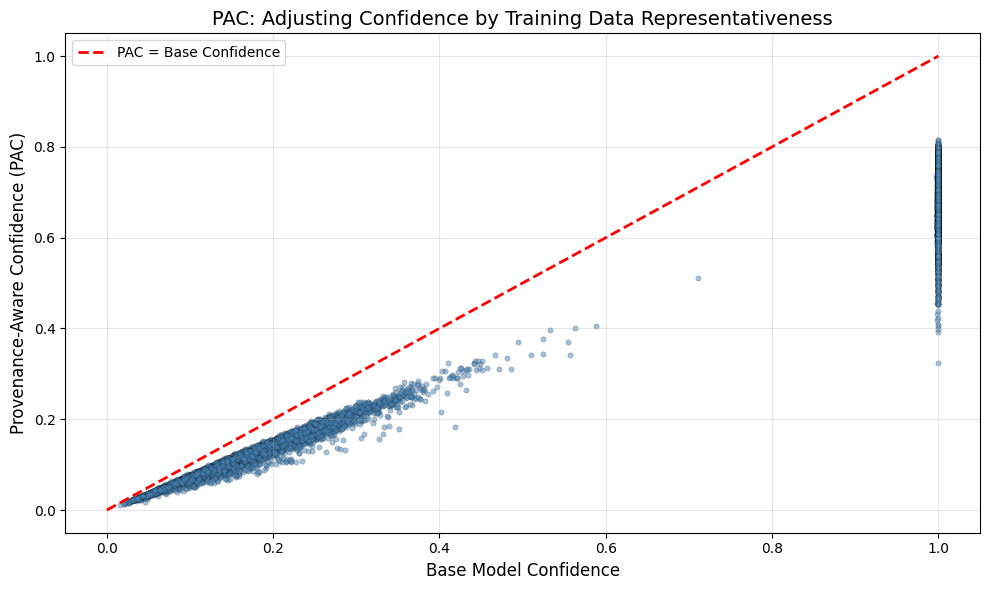

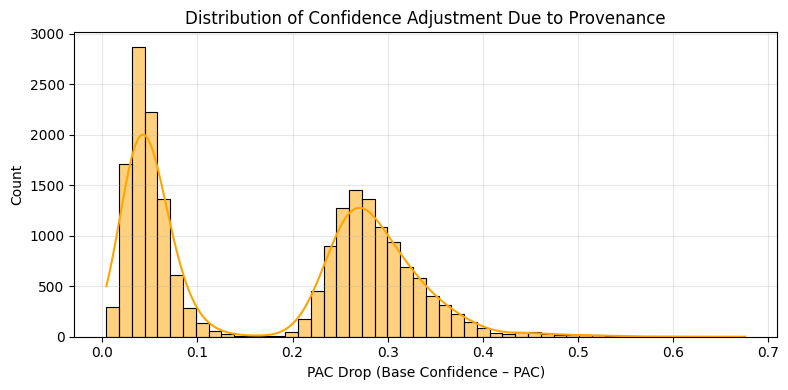


🏥 Clinical Triage Summary:
   Total high-risk predictions: 10,407
   ✅ Auto-approve (PAC ≥ 0.6): 10,094
   ⚠️ Flag for clinician review (PAC < 0.3): 9,568

📋 Top 3 Flagged Cases for Clinician Review:

1. Patient test_11346
   - Predicted risk: 1.5% → PAC: 1.1%
   - Patient: Female, Age 39
   - Training support: 51% same gender, Age similarity=0.86
   - Neighborhood diabetes rate: 11.0%
   → Recommendation: Confirm with clinical assessment or HbA1c test.

2. Patient test_17853
   - Predicted risk: 2.1% → PAC: 1.4%
   - Patient: Male, Age 18
   - Training support: 43% same gender, Age similarity=0.75
   - Neighborhood diabetes rate: 16.0%
   → Recommendation: Confirm with clinical assessment or HbA1c test.

3. Patient test_9192
   - Predicted risk: 2.1% → PAC: 1.4%
   - Patient: Female, Age 18
   - Training support: 52% same gender, Age similarity=0.74
   - Neighborhood diabetes rate: 9.0%
   → Recommendation: Confirm with clinical assessment or HbA1c test.

✅ Audit logs saved to: pac_a

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

# 2. CONFIGURATION
CSV_FILE = '/content/diabetes_dataset.csv'
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_NEIGHBORS = 100
PAC_FLAG_THRESHOLD = 0.3    # Flag if PAC < this
PAC_APPROVE_THRESHOLD = 0.6 # Auto-approve if PAC >= this

# 3. LOAD AND VALIDATE DATA
print("🔍 Loading dataset...")
if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(f"❌ '{CSV_FILE}' not found. Please upload it via Colab sidebar.")

df = pd.read_csv(CSV_FILE)
print(f"✅ Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

# 4. PREPROCESSING
# Target: 'diagnosed_diabetes' (0 = No, 1 = Yes)
y = df['diagnosed_diabetes'].astype(int)

# Features: exclude target and stage
feature_cols = [col for col in df.columns if col not in ['diagnosed_diabetes', 'diabetes_stage']]
X_raw = df[feature_cols].copy()

# Encode categorical variables
categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level',
                    'employment_status', 'smoking_status']
X_encoded = X_raw.copy()

label_encoders = {}
for col in categorical_cols:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le

print(f"✅ Encoded {len(categorical_cols)} categorical features.")
print(f"✅ Final feature set: {X_encoded.shape[1]} features")

# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)
print(f"\nSplitOptions: Train={X_train.shape[0]:,}, Test={X_test.shape[0]:,}")

# 6. MODEL TRAINING
print("\n🚀 Training XGBoost model...")
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# 7. BASELINE EVALUATION
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

base_acc = accuracy_score(y_test, y_pred)
base_auc = roc_auc_score(y_test, y_proba)
base_brier = brier_score_loss(y_test, y_proba)

print(f"\n📊 Baseline Model Performance:")
print(f"   Accuracy: {base_acc:.4f}")
print(f"   AUC:      {base_auc:.4f}")
print(f"   Brier:    {base_brier:.4f}")

# 8. COMPUTE PROVENANCE-AWARE CONFIDENCE (PAC)
print(f"\n🔍 Computing Provenance-Aware Confidence (PAC) using k={N_NEIGHBORS} neighbors...")

# Fit nearest neighbors on encoded training set
nn = NearestNeighbors(n_neighbors=N_NEIGHBORS, metric='euclidean')
nn.fit(X_train)

# Retrieve original age and gender for test set (before encoding)
X_test_original = df.loc[X_test.index, ['age', 'gender']].copy()

# Compute PAC for each test patient
pac_scores = []
pac_audit_logs = []

for i in range(len(X_test)):
    # Get neighborhood indices
    _, neighbor_indices = nn.kneighbors(X_test.iloc[[i]])
    neighbor_idxs = X_train.iloc[neighbor_indices[0]].index

    # Original attributes for neighborhood
    neighbors_original = df.loc[neighbor_idxs, ['age', 'gender']]

    # Test patient attributes
    test_age = X_test_original.iloc[i]['age']
    test_gender = X_test_original.iloc[i]['gender']
    base_conf = y_proba[i]

    # 1. Gender match rate
    gender_match = (neighbors_original['gender'] == test_gender).mean()

    # 2. Age similarity (normalize by plausible range: 18–90 → max diff = 72)
    age_diffs = np.abs(neighbors_original['age'] - test_age)
    mean_age_diff = age_diffs.mean()
    age_similarity = max(0.0, 1.0 - (mean_age_diff / 72.0))

    # 3. Outcome consistency (how aligned is neighborhood risk?)
    neighbors_y = y_train.loc[neighbor_idxs]
    neighborhood_risk = neighbors_y.mean()
    outcome_consistency = 1.0 - abs(neighborhood_risk - base_conf)

    # Combine into similarity score
    similarity_score = (
        0.4 * gender_match +
        0.4 * age_similarity +
        0.2 * outcome_consistency
    )

    # PAC = base confidence × similarity
    pac = base_conf * similarity_score

    # Log for auditability
    pac_audit_logs.append({
        "patient_id": f"test_{i}",
        "base_confidence": float(base_conf),
        "pac_score": float(pac),
        "gender_match_rate": float(gender_match),
        "age_similarity": float(age_similarity),
        "outcome_consistency": float(outcome_consistency),
        "neighborhood_diabetes_rate": float(neighborhood_risk),
        "test_age": int(test_age),
        "test_gender": str(test_gender),
        "prediction": int(y_pred[i]),
        "true_label": int(y_test.iloc[i])
    })

    pac_scores.append(pac)

pac_scores = np.array(pac_scores)
print(f"✅ PAC computed for {len(pac_scores):,} patients.")

# 9. ANALYSIS & VISUALIZATION
print(f"\n📈 PAC Analysis:")
print(f"   Mean Base Confidence: {y_proba.mean():.4f}")
print(f"   Mean PAC:             {pac_scores.mean():.4f}")
print(f"   Correlation (PAC vs Base): {np.corrcoef(pac_scores, y_proba)[0,1]:.4f}")

# Plot 1: PAC vs Base Confidence
plt.figure(figsize=(10, 6))
plt.scatter(y_proba, pac_scores, alpha=0.5, s=15, color='steelblue', edgecolor='k', linewidth=0.2)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='PAC = Base Confidence')
plt.xlabel('Base Model Confidence', fontsize=12)
plt.ylabel('Provenance-Aware Confidence (PAC)', fontsize=12)
plt.title('PAC: Adjusting Confidence by Training Data Representativeness', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: PAC drop distribution
pac_drop = y_proba - pac_scores
plt.figure(figsize=(8, 4))
sns.histplot(pac_drop, bins=50, kde=True, color='orange')
plt.xlabel('PAC Drop (Base Confidence – PAC)')
plt.title('Distribution of Confidence Adjustment Due to Provenance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. CLINICAL TRIAGE DECISIONS
auto_approve = (pac_scores >= PAC_APPROVE_THRESHOLD) & (y_pred == 1)
flag_for_review = pac_scores < PAC_FLAG_THRESHOLD

print(f"\n🏥 Clinical Triage Summary:")
print(f"   Total high-risk predictions: {y_pred.sum():,}")
print(f"   ✅ Auto-approve (PAC ≥ {PAC_APPROVE_THRESHOLD}): {auto_approve.sum():,}")
print(f"   ⚠️ Flag for clinician review (PAC < {PAC_FLAG_THRESHOLD}): {flag_for_review.sum():,}")

# Show top 3 flagged cases
if flag_for_review.sum() > 0:
    flagged_indices = np.where(flag_for_review)[0]
    top_flagged = flagged_indices[np.argsort(pac_scores[flagged_indices])[:3]]

    print(f"\n📋 Top 3 Flagged Cases for Clinician Review:")
    for rank, idx in enumerate(top_flagged, 1):
        log = pac_audit_logs[idx]
        print(f"\n{rank}. Patient {log['patient_id']}")
        print(f"   - Predicted risk: {log['base_confidence']:.1%} → PAC: {log['pac_score']:.1%}")
        print(f"   - Patient: {log['test_gender']}, Age {log['test_age']}")
        print(f"   - Training support: {log['gender_match_rate']:.0%} same gender, "
              f"Age similarity={log['age_similarity']:.2f}")
        print(f"   - Neighborhood diabetes rate: {log['neighborhood_diabetes_rate']:.1%}")
        print(f"   → Recommendation: Confirm with clinical assessment or HbA1c test.")

# 11. SAVE AUDIT LOGS (FOR ACCOUNTABILITY)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
audit_dir = "pac_audit_logs"
os.makedirs(audit_dir, exist_ok=True)

# Full audit log (JSONL)
audit_path = os.path.join(audit_dir, f"pac_audit_{timestamp}.jsonl")
with open(audit_path, "w") as f:
    for log in pac_audit_logs:
        f.write(json.dumps(log) + "\n")

# Summary metrics (JSON)
summary = {
    "timestamp": timestamp,
    "dataset": CSV_FILE,
    "model": "XGBoost",
    "base_metrics": {
        "accuracy": float(base_acc),
        "auc": float(base_auc),
        "brier_score": float(base_brier)
    },
    "pac_metrics": {
        "mean_pac": float(pac_scores.mean()),
        "flagged_for_review": int(flag_for_review.sum()),
        "auto_approved": int(auto_approve.sum())
    },
    "config": {
        "n_neighbors": N_NEIGHBORS,
        "pac_flag_threshold": PAC_FLAG_THRESHOLD,
        "pac_approve_threshold": PAC_APPROVE_THRESHOLD
    }
}

summary_path = os.path.join(audit_dir, f"pac_summary_{timestamp}.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Audit logs saved to: {audit_dir}/")
print("🎉 Provenance-Aware Confidence pipeline completed successfully!")